# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AsserGharib1/flyrank-internshipML/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

This runs in Colab or on your own machine. It only loads the small anonymized dataset that ships with this repo. No credentials, no private data.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AsserGharib1/flyrank-internshipML"
REPO_DIR = "flyrank-internshipML"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found. Are you at the repo root?"

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print("Working dir:", os.getcwd())
print("Starter dataset:", df.shape[0], "rows and", df.shape[1], "columns")
print("Pseudonymized clients:", df.client_id.nunique())

Working dir: /tmp/fresh
Starter dataset: 30000 rows and 44 columns
Pseudonymized clients: 32


## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

**My lane is Lane 2, Refresh and Content Opportunity Scoring.**

**The task type is ranking.** Underneath it I use a yes or no classifier. Those are not two competing
answers. They are two layers of the same system, and knowing which is which matters.

The decision I want to improve is not "will this page fall". Nobody acts on that sentence. The real
decision is this. An editor has time to review a set number of pages this week. Which ones?

That is a ranking problem. The output is a list, read from the top, with a cut off. What makes it
hard is not judging one page on its own. It is deciding which pages matter more than others when
thousands of them are competing for the same few hours.

I get the ranking from a classifier. I train a model to estimate the chance that a page falls behind
its peers in the next window. Then I sort by that chance and cut the list at the top. The classifier
is the machine. The ranking is the product.

This changes what I measure. I care about the top of the list only. Nobody ever reads the bottom.

**Who acts on it, and what they actually do.** A content editor or an SEO reviewer working through a
weekly queue. The ranking on its own is not useful. What they need is a queue where every row comes
with an action they can take that day.

* **Refresh.** The page still has demand but is losing it, and the content has gone stale.
* **Expand.** Demand is holding, but the page is too thin for what people are searching for.
* **Protect and watch.** A strong page has slipped a little. Keep an eye on it. Do not touch it yet.
* **Prune or merge.** Demand has gone, and another page already covers the same ground.

Every row also carries **reason codes**. These are short tags that say why the page showed up. The
editor can then disagree with the model before spending an hour on it. A queue nobody can argue with
is a queue nobody trusts. Building the actions and reason codes is ML-07 work. Naming them now is
what keeps this a tool that supports a decision instead of just a score.

**What a wrong answer costs.** The two mistakes are not equal, and that shapes the design.

A false alarm costs one wasted review. The editor opens a healthy page, finds nothing, and moves on.
Maybe an hour.

A miss costs more. A page keeps fading for another cycle with nobody watching, and the longer that
runs the harder it is to bring back.

So missing is worse than over flagging. I will trade some precision to protect recall. But only so
far. If the queue fills with junk the editor stops opening it, and then the real precision is zero.

**Why not the other lanes.** Clustering, which is Lane 3, describes what kinds of pages exist. It
does not tell anyone what to do first. Signal analysis, which is Lane 1, builds understanding rather
than a queue. Both are worth doing. Neither ends in a decision an editor makes on a Monday.

In [2]:
# The decision in numbers. How much sorting does the ranking really have to do?

MIN_PRIOR_IMPRESSIONS = 100   # my choice. Below this, movement is mostly noise. Revisited in section 3.

eligible = df[df.impressions_prev_30d >= MIN_PRIOR_IMPRESSIONS]

print("Pages in the starter slice:          ", len(df))
print("Pages with enough demand to matter:  ", len(eligible), f"({len(eligible)/len(df):.1%})")
print("Pseudonymized clients covered:       ", eligible.client_id.nunique())
print()
for capacity in (20, 50, 100):
    print(f"  editor reviews {capacity:>3} pages, so the ranking has to find the top "
          f"{capacity/len(eligible):.2%} of the pool")
print()
print("This is why the task is ranking and not accuracy.")
print("More than 99 percent of the list never gets opened.")

Pages in the starter slice:           30000
Pages with enough demand to matter:   18010 (60.0%)
Pseudonymized clients covered:        30

  editor reviews  20 pages, so the ranking has to find the top 0.11% of the pool
  editor reviews  50 pages, so the ranking has to find the top 0.28% of the pool
  editor reviews 100 pages, so the ranking has to find the top 0.56% of the pool

This is why the task is ranking and not accuracy.
More than 99 percent of the list never gets opened.


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

This is where my first answer broke and I had to build a new one. Two things went wrong, in order.

### What went wrong the first time

The starter pipeline predicts whether the trend direction column says "down". So I went looking for
where that column comes from.

It is a rule. Nothing more. A page is marked "down" when impressions in the last 30 days fell more
than 10 percent against the 30 days before. I checked all 16,262 rows marked "down" and every single
one fits that rule exactly. Same story for "up" at plus 10 percent.

So the starter model scoring 0.750 is not a discovery. It is a model working out an if statement that
was handed to it in the same file. The framing skill puts it simply. The target has to be something
you observed, not something you defined. If it was defined, start again.

### What went wrong the second time

The obvious fix is a real future window. Take features from an earlier period and measure the outcome
in a later one. So I checked what falling actually looks like in this data.

**Almost everything is falling.** Seven pages in ten dropped. The middle page lost about a third of
its impressions. This is not small pages being noisy either. Every single volume group falls, from
the smallest to the largest, and the link between size and change is basically zero. Seventeen of the
eighteen clients have a negative middle value.

The whole snapshot is going down. So a model trained on plain decline would mostly learn that this
period was bad, and then report that back as if it were skill. That is the trap the lane guide warns
about twice, once about seasonality and once about mistaking normal seasonal movement for a model
being clever. It would have been the same circular mistake as the first one, just harder to spot.

### The target I settled on

**Falling behind your own client.** A page counts as positive when it dropped clearly more than a
typical page on the same site over the same window.

```
change      = (impressions after - impressions before) / impressions before * 100
gap         = change - the middle change across that client's pages
label       = 1 when gap is 10 points or worse
```

Taking out each client's own middle value removes the market wide drop and leaves the part that is
really about this page. It brings the positive rate down from about 71 percent to about 37 percent.
That is a healthier number, and it means something an editor can act on.

**Where the label comes from.** A real measured outcome. Impressions in a later window. Never a
product decision and never a precalculated flag. The trend direction and trend percent columns are
thrown out of the features completely, because they are the answer wearing a disguise.

**On the capstone** the two windows are real and do not touch. Features from the prior 90 days of the
daily table, outcome from the next 30 days.

The starter file has no future window at all. So below I build the same shape of label using the
earlier 30 days against the later 30 days. That is a stand in. It shows how the label is built and
what the base rate looks like. I am calling it a stand in rather than pretending it is the real
thing.

**What I still do not know.** Which client a page belongs to explains only about 12 percent of the
movement. The other 88 percent happens inside a client, and I cannot tell from a 90 day summary
whether that is real signal or just noise. Daily data would answer it. That is the first question my
ML-04 data contract has to settle. If the answer turns out to be noise, this lane does not survive
and I switch rather than publish a number I cannot stand behind.

In [3]:
# Where does the trend direction column come from? Is it measured, or is it a rule?

chk = df[df.impressions_prev_30d > 0].copy()
chk["rebuilt_change"] = (
    (chk.impressions_last_30d - chk.impressions_prev_30d) / chk.impressions_prev_30d * 100
)

down = chk[chk.trend_direction == "down"]
up   = chk[chk.trend_direction == "up"]

print("Can I rebuild the trend column from two raw columns?")
print(f"  rows marked down that fit 'fell more than 10 percent' : {(down.rebuilt_change < -10).sum():>6} of {len(down)}")
print(f"  rows marked up   that fit 'rose more than 10 percent' : {(up.rebuilt_change   >  10).sum():>6} of {len(up)}")
print()
print("It matches every time. So this column is a rule someone wrote, not an outcome anyone measured.")
print("I am dropping it from the features and I am not using it as my target.")

Can I rebuild the trend column from two raw columns?
  rows marked down that fit 'fell more than 10 percent' :  16262 of 16262
  rows marked up   that fit 'rose more than 10 percent' :   4388 of 4388

It matches every time. So this column is a rule someone wrote, not an outcome anyone measured.
I am dropping it from the features and I am not using it as my target.


In [4]:
# Is the falling specific to certain pages, or is the whole snapshot going down?

mv = df[df.impressions_prev_30d >= MIN_PRIOR_IMPRESSIONS].copy()
mv["change_pct"] = (
    (mv.impressions_last_30d - mv.impressions_prev_30d) / mv.impressions_prev_30d * 100
)

print("Looking at plain decline across every page that qualifies")
print(f"  middle change             : {mv.change_pct.median():.1f} percent")
print(f"  share that fell over 10%  : {(mv.change_pct < -10).mean():.1%}")
print()

# Maybe it is just small pages being noisy. Check every size group.
mv["size_group"] = pd.qcut(mv.impressions_prev_30d, 10, labels=False, duplicates="drop")
by_group = mv.groupby("size_group").agg(
    pages=("change_pct", "size"),
    typical_size_before=("impressions_prev_30d", "median"),
    pct_that_fell=("change_pct", lambda s: (s < -10).mean() * 100),
    middle_change=("change_pct", "median"),
).round(1)
print("Falling rate by size group, smallest at the top:")
print(by_group.to_string())
print()
print("Link between size and change = "
      f"{np.corrcoef(np.log1p(mv.impressions_prev_30d), mv.change_pct.clip(-200, 200))[0,1]:.3f}")
print("Every group falls. So this is not small pages being noisy. The whole snapshot is going down.")

Looking at plain decline across every page that qualifies
  middle change             : -31.8 percent
  share that fell over 10%  : 70.9%

Falling rate by size group, smallest at the top:
            pages  typical_size_before  pct_that_fell  middle_change
size_group                                                          
0            1814                126.0           68.0          -36.0
1            1790                196.0           67.9          -34.8
2            1803                293.0           71.4          -34.9
3            1802                436.0           74.8          -35.9
4            1802                658.0           73.4          -35.4
5            1799                981.0           74.9          -35.2
6            1798               1518.0           72.2          -31.7
7            1801               2471.0           70.3          -28.6
8            1800               4499.5           68.8          -27.0
9            1801              11890.0           67.2

In [5]:
# Building the target. Falling behind your own client.

client_middle = mv.groupby("client_id").change_pct.transform("median")
mv["gap_vs_client"] = mv.change_pct - client_middle

FALLING_BEHIND_CUTOFF = -10   # my choice, defended in section 3
mv["target_falls_behind"] = (mv.gap_vs_client <= FALLING_BEHIND_CUTOFF).astype(int)

per_client = (mv.groupby("client_id")
                .agg(pages=("change_pct", "size"), middle_change=("change_pct", "median"))
                .query("pages >= 50")
                .sort_values("middle_change").round(1))
print("Clients with at least 50 qualifying pages. How a typical page moved:")
print(per_client.to_string())
print()
print(f"  clients where the typical page went UP: {(per_client.middle_change > 0).sum()} of {len(per_client)}")
print()

total_spread = mv.change_pct.clip(-300, 300).var()
left_over    = (mv.change_pct - client_middle).clip(-300, 300).var()
print(f"How much of the movement is explained just by which client a page belongs to: "
      f"{(1 - left_over/total_spread):.1%}")
print("So the client sets the level, but most of the movement still happens inside a client.")
print("Whether that leftover is real signal or noise is the open question for ML-04.")
print()
print("What the reframe does to the target")
print(f"  plain fall of more than 10 percent      : positive rate {(mv.change_pct < -10).mean():.3f}")
print(f"  falls 10 points behind its own client   : positive rate {mv.target_falls_behind.mean():.3f}")

Clients with at least 50 qualifying pages. How a typical page moved:
                   pages  middle_change
client_id                              
client_7f2253d7e2    970          -65.5
client_a88a7902cb    423          -58.5
client_3fdba35f04   1686          -57.8
client_9400f1b21c     86          -46.3
client_4ec9599fc2    186          -45.2
client_d029fa3a95    188          -41.5
client_f369cb89fc    634          -41.1
client_f74efabef1    568          -37.6
client_349c41201b    705          -36.5
client_6208ef0f77   3352          -32.6
client_bbb965ab0c    399          -30.5
client_624b60c58c     94          -27.3
client_e629fa6598    156          -24.2
client_19581e27de   5690          -20.8
client_b4944c6ff0    186          -20.2
client_4e07408562   2168          -19.2
client_8527a891e2    144          -10.5
client_2c624232cd    176           10.1

  clients where the typical page went UP: 1 of 18

How much of the movement is explained just by which client a page belongs to: 1

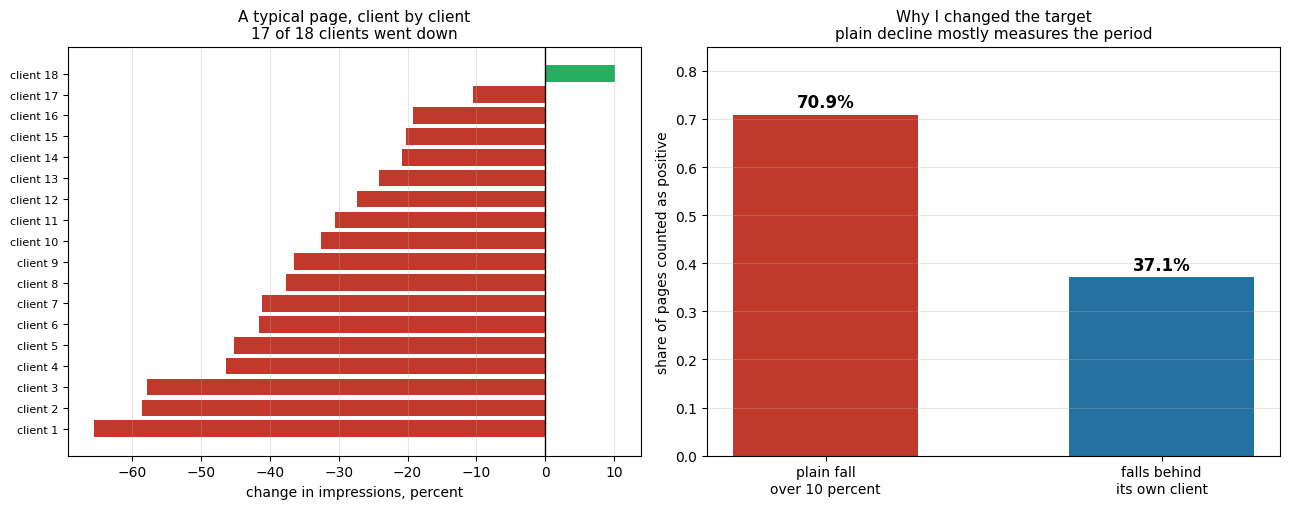

Left: almost every client fell, so a plain decline label mostly captures the period.
Right: comparing each page to its own client cuts the positive rate roughly in half,
and what is left is the part that is really about the page.


In [6]:
# One picture of the two findings that decided my target.

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Left: how a typical page moved, client by client.
p = per_client.sort_values("middle_change")
colors = ["#c0392b" if v < 0 else "#27ae60" for v in p.middle_change]
axes[0].barh(range(len(p)), p.middle_change, color=colors)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_yticks(range(len(p)))
axes[0].set_yticklabels([f"client {i+1}" for i in range(len(p))], fontsize=8)
axes[0].set_xlabel("change in impressions, percent")
axes[0].set_title("A typical page, client by client\n17 of 18 clients went down", fontsize=11)
axes[0].grid(axis="x", alpha=0.3)

# Right: what the reframe does to the base rate.
plain = (mv.change_pct < -10).mean()
rel   = mv.target_falls_behind.mean()
bars = axes[1].bar(["plain fall\nover 10 percent", "falls behind\nits own client"],
                   [plain, rel], color=["#c0392b", "#2471a3"], width=0.55)
for b, v in zip(bars, [plain, rel]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.015, f"{v:.1%}",
                 ha="center", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 0.85)
axes[1].set_ylabel("share of pages counted as positive")
axes[1].set_title("Why I changed the target\nplain decline mostly measures the period", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: almost every client fell, so a plain decline label mostly captures the period.")
print("Right: comparing each page to its own client cuts the positive rate roughly in half,")
print("and what is left is the part that is really about the page.")

## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Precision at 50.** Out of the 50 pages my ranking puts at the top, how many really did fall behind
their peers.

**Why this one.** It is the only measure shaped like the actual decision. An editor works through a
set number of pages, from the top, in order.

Accuracy would reward me for correctly calling thousands of pages fine. Nobody will ever open those.
A whole ranking score like ROC AUC grades the entire list including the part nobody reads. Precision
at 50 grades exactly the part that gets used.

I picked it before training anything. That is the whole point of writing it down here. A target you
choose after seeing the results always looks like a target you hit.

**What good means, as a number I can be held to.** The base rate is about 0.371, so picking 50 pages
at random would get about 19 right. That is the floor.

The real bar is the plain rule baseline I build in ML-07. A model that cannot beat a simple rule has
not earned the extra complexity, and I would say so rather than hide it.

My target is **precision at 50 of 0.60 or better**, which is about 30 pages out of 50. It also has to
beat the rule baseline by enough that the gap survives holding whole clients out of training.

If it lands below that, the honest write up is that the rule was good enough. That is a real result,
not a failure.

**Always reported next to it.** The base rate, so the number can be read properly. Recall at the same
cut off, because missing a real problem costs more than a wasted review. And the baseline score on
exactly the same split. A precision number published without its base rate is decoration, not a
claim.

**Second measure.** Average precision, for when the whole ordering matters rather than one cut off.

**How I will validate.** Hold out whole clients. Pages on the same site share templates, site wide
movements, and one CMS. A random split would let the model memorize a client and then test itself on
that same client. For the capstone the split also has to respect time, because the outcome sits in a
future window.

In [7]:
# What is the floor for this metric, and can I compute it today on real rows?

base_rate = mv.target_falls_behind.mean()

print(f"Base rate of positives                  : {base_rate:.3f}")
print(f"Picking 50 pages at random would get    : about {base_rate*50:.0f} of 50 right")
print(f"My stated bar of 0.60 means             : about 30 of 50 right")
print(f"So I need to beat random by             : {0.60/base_rate:.2f} times")
print()

# Floor check. What does an obvious one signal rule get, using only things known
# before the outcome window? Feature safety is worked out in section 4.
for label, ranked in [
    ("fewest clicks in the earlier window", mv.nsmallest(50, "clicks_prev_30d")),
    ("longest since it was updated",        mv.nlargest(50, "days_since_last_update")),
]:
    print(f"  simple rule, {label:<36} precision at 50 = "
          f"{ranked.target_falls_behind.mean():.3f}")
print()
print(f"Both land at or under the base rate of {base_rate:.3f}. A simple rule is not free lift here.")
print("The metric is computable today, on real rows. It is not hypothetical.")

Base rate of positives                  : 0.371
Picking 50 pages at random would get    : about 19 of 50 right
My stated bar of 0.60 means             : about 30 of 50 right
So I need to beat random by             : 1.62 times

  simple rule, fewest clicks in the earlier window  precision at 50 = 0.360
  simple rule, longest since it was updated         precision at 50 = 0.320

Both land at or under the base rate of 0.371. A simple rule is not free lift here.
The metric is computable today, on real rows. It is not hypothetical.


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

**One row is one piece of content, looked at on one decision date.**

Not one web address. Not one page per day. Not one client. The thing being ranked is a page, and what
makes it rankable is the moment somebody decided to look at it.

Getting this wrong is how leakage sneaks in. If a row quietly means "one page across all time", then
the window I take features from and the window I measure the outcome in end up mixed together without
me noticing.

In the starter file the decision date is fixed. One snapshot, one row per piece of content, already
deduplicated. So the row is simply one piece of content.

On the warehouse the daily table is one row per client per content per day, so I have to build this
shape myself. Pick the decision dates, roll the prior 90 days into features, attach the next 30 days
as the outcome. Same shape, built rather than handed over.

**What sits in a row.** The scrambled keys, used for joining and grouping only and never as features.
The measured search and engagement signals from the earlier window. And the target from section 2.

### The mistake I caught in my own first draft

My first list of features was the obvious one. Impressions, clicks, sessions, click through rate and
active days, all measured over 90 days.

Then I ran the lane guide's own leakage question against my own list. Does the feature window overlap
the outcome window? The answer was yes.

**The 90 day window contains the last 30 days, and the last 30 days is my outcome.** The 90 day
impressions column moves almost in lockstep with the outcome, at 0.916. I had just spent a whole
section arguing that the trend column leaks, and then handed the model five features that leak the
same way, only more quietly.

I am keeping both versions below instead of deleting the first one. The point of this assignment is
the checking, not the answer.

The corrected list uses only what was genuinely known on the decision date. Signals from the earlier
window, plus fixed facts about the content like word count, age, how long since it was updated,
search volume and competition.

The earlier window impressions are safe to use even though the outcome is worked out from them,
because they were fully measured before the decision date. The outcome lives entirely in the later
window, and that window never touches the features.

This is the same habit I carry to the warehouse. Build the two windows first. Prove they do not
touch. Then model.

**Safe to publish.** No client names, no web addresses, no search terms, no titles. The ids below are
scrambled codes and are only shown so the shape of a row is visible.

In [8]:
# One row is one piece of content on one decision date. Show it rather than claim it.

print("Checking the shape of a row")
print(f"  rows                          : {len(mv)}")
print(f"  different pieces of content   : {mv.content_id.nunique()}")
print(f"  rows per piece of content     : {len(mv)/mv.content_id.nunique():.2f}   (1.00 means the shape is clean)")
print(f"  decision dates in this file   : 1 fixed snapshot. Built by hand on the warehouse.")
print()

FIRST_DRAFT_FEATURES = ["impressions_90d", "clicks_90d", "sessions_90d", "ctr", "days_with_impressions"]

print("Checking my own first draft for leakage")
print("  the outcome sits in the last 30 days")
print("  the question from the lane guide: does the feature window overlap the outcome window?")
print()
for col in FIRST_DRAFT_FEATURES:
    ok = mv[col].notna()
    r = np.corrcoef(mv.loc[ok, col], mv.loc[ok, "impressions_last_30d"])[0, 1]
    note = "LEAKS. The 90 day window contains the outcome." if abs(r) > 0.30 else "small overlap"
    print(f"  link with the outcome, {col:<22} = {r:>6.3f}   {note}")
print()
print("So the 90 day columns stretch across the outcome window. All of them are dropped.")

Checking the shape of a row
  rows                          : 18010
  different pieces of content   : 18010
  rows per piece of content     : 1.00   (1.00 means the shape is clean)
  decision dates in this file   : 1 fixed snapshot. Built by hand on the warehouse.

Checking my own first draft for leakage
  the outcome sits in the last 30 days
  the question from the lane guide: does the feature window overlap the outcome window?

  link with the outcome, impressions_90d        =  0.916   LEAKS. The 90 day window contains the outcome.
  link with the outcome, clicks_90d             =  0.626   LEAKS. The 90 day window contains the outcome.
  link with the outcome, sessions_90d           =  0.553   LEAKS. The 90 day window contains the outcome.
  link with the outcome, ctr                    =  0.072   small overlap
  link with the outcome, days_with_impressions  =  0.115   small overlap

So the 90 day columns stretch across the outcome window. All of them are dropped.


In [9]:
# The corrected slice. Only what was knowable on the decision date.

EARLIER_WINDOW = ["impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d"]
FIXED_FACTS = ["word_count", "char_count", "content_age_days",
               "days_since_last_update", "search_volume", "competition", "age_tier_order"]
FEATURE_COLUMNS = EARLIER_WINDOW + FIXED_FACTS

DROPPED = {
    "trend direction and trend percent": "a rule that restates the outcome, see section 2",
    "the five 90 day columns":           "their window overlaps the outcome window, see the check above",
    "the later 30 day columns":          "this is the outcome itself",
}

slice_df = mv[["content_id", "client_id"] + FEATURE_COLUMNS +
              ["gap_vs_client", "target_falls_behind"]].copy()

print(f"Features kept, {len(FEATURE_COLUMNS)} in total")
print(f"  from the earlier window : {EARLIER_WINDOW}")
print(f"  fixed facts             : {FIXED_FACTS}")
print()
print("Dropped, with the reason written down:")
for what, why in DROPPED.items():
    print(f"  {what}")
    print(f"      {why}")
print()
print("The unit of analysis, as a real dataframe:")
print(slice_df.head(5).to_string(index=False))
print()
print("What the target column looks like:")
print(slice_df.target_falls_behind.value_counts()
        .rename({0: "0 = kept up with its client", 1: "1 = fell behind its client"}).to_string())
print()
print(f"Gaps to deal with in ML-04: word count and character count are missing on "
      f"{mv.word_count.isna().mean():.0%} of rows, search volume and competition on "
      f"{mv.search_volume.isna().mean():.0%}.")

Features kept, 10 in total
  from the earlier window : ['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d']
  fixed facts             : ['word_count', 'char_count', 'content_age_days', 'days_since_last_update', 'search_volume', 'competition', 'age_tier_order']

Dropped, with the reason written down:
  trend direction and trend percent
      a rule that restates the outcome, see section 2
  the five 90 day columns
      their window overlaps the outcome window, see the check above
  the later 30 day columns
      this is the outcome itself

The unit of analysis, as a real dataframe:
          content_id         client_id  impressions_prev_30d  clicks_prev_30d  sessions_prev_30d  word_count  char_count  content_age_days  days_since_last_update  search_volume  competition  age_tier_order  gap_vs_client  target_falls_behind
content_304f48230142 client_f369cb89fc                   987               13                  9      3221.0     20457.0               187                  

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

Let me be straight first. **A rule might win, and I have to leave room for that.** FlyRank already
runs hand written rules in production and they work. The framing skill says a model only earns its
place when the pattern is real but too tangled to write out by hand. So what follows is something I
plan to test in ML-07 and ML-08, not something I am assuming.

**What makes me think the pattern is tangled.** I sorted the pool by each safe signal on its own and
checked how well each one separates pages that fell behind.

The best single signal reaches about 0.61, where 0.50 is a coin toss. Most of them sit between 0.50
and 0.55.

Then I tried the two most obvious rules anyone would write by hand. Fewest clicks last month, and
oldest content. They score 0.360 and 0.320 against a base rate of 0.371. Both land at or below
chance.

So there is no simple cut off waiting to be found. If there were one, the honest answer to this
assignment would be to write the rule and skip the model entirely.

**Three reasons a plain rule struggles here.**

First, **the cut offs move depending on context.** Low click through means one thing at position 3
and something else at position 15. Stale means one thing for a news page and something else for a
reference page. A rule needs its own branch for every combination, and the number of branches gets
out of hand fast. That is usually where rule systems stop scaling. Not because any single rule is
wrong, but because there are too many of them to keep straight.

Second, **the baseline moves under your feet.** Section 2 showed clients whose typical page ranged
from down 65 percent to up 10 percent. A fixed rule like "flag anything down 20 percent" flags nearly
every page at one client and almost nothing at another. My target already corrects for this. The fact
that I had to build that correction in is itself evidence a fixed cut off cannot hold.

Third, **the signals are weak on their own and only get useful in combination.** That is exactly the
situation where a model earns its keep, and exactly where hand tuning gives up.

**What would change my mind.** If the rule baseline matches the model on precision at 50 with whole
clients held out, I ship the rule and say so plainly. A simple rule that ties a model is the better
product. You can read it, explain it to an editor, and run it cheaply. "The model did not beat the
rule" is a publishable result, and pretending otherwise is how circular findings end up in print.

One more thing worth saying out loud. On my leaky first feature list, a single signal rule scored
0.740, comfortably past my own bar. That number came entirely from the overlap I caught in section 4.
A result that looks too good is a reason to go checking, not a reason to celebrate.

In [10]:
# Is there a simple one signal rule hiding in here? Sort by each signal alone and score it.

from sklearn.metrics import roc_auc_score

y = mv.target_falls_behind

rows = []
for col in FEATURE_COLUMNS:
    s = mv[col]
    ok = s.notna()
    if ok.sum() < 500 or y[ok].nunique() < 2:
        continue
    score = roc_auc_score(y[ok], s[ok])
    rows.append({
        "signal": col,
        "rows available": f"{ok.mean():.0%}",
        "score alone": round(max(score, 1 - score), 3),
    })

single = pd.DataFrame(rows).sort_values("score alone", ascending=False)
print("How well does each safe signal separate pages that fell behind, on its own?")
print(single.to_string(index=False))
print()
print(f"Best single signal is {single.iloc[0].signal} at {single.iloc[0]['score alone']}, "
      "where 0.50 is a coin toss.")
print()

leaky = []
for col in FIRST_DRAFT_FEATURES:
    ok = mv[col].notna()
    s = roc_auc_score(y[ok], mv.loc[ok, col])
    leaky.append(round(max(s, 1 - s), 3))
leaky_rule = mv.nsmallest(50, "days_with_impressions").target_falls_behind.mean()

print(f"For comparison, the 90 day columns I dropped scored {min(leaky)} to {max(leaky)} on their own,")
print(f"and a simple rule built on one of them hit precision at 50 of {leaky_rule:.3f}.")
print("That is past my own bar and completely meaningless, because those columns")
print("stretch across the outcome window. A number that looks great is a reason to go checking.")
print()
print("Nothing in the safe set works as a rule on its own. That is the case for letting a model")
print("combine them. It still has to be tested against a rule baseline in ML-07 and ML-08.")
print()
print("Being careful about claims: this is what I observed on a 30,000 row anonymized sample,")
print("using a stand in outcome window. It points in a direction and it supports a decision.")
print("It does not prove cause, and it says nothing about how Google ranks pages.")

How well does each safe signal separate pages that fell behind, on its own?
                signal rows available  score alone
       clicks_prev_30d           100%        0.612
     sessions_prev_30d           100%        0.611
  impressions_prev_30d           100%        0.551
        age_tier_order           100%        0.536
      content_age_days           100%        0.532
         search_volume            98%        0.517
            word_count            71%        0.515
            char_count            71%        0.510
           competition            98%        0.506
days_since_last_update           100%        0.503

Best single signal is clicks_prev_30d at 0.612, where 0.50 is a coin toss.

For comparison, the 90 day columns I dropped scored 0.585 to 0.626 on their own,
and a simple rule built on one of them hit precision at 50 of 0.740.
That is past my own bar and completely meaningless, because those columns
stretch across the outcome window. A number that looks great i

## Self-check

Before you submit, confirm each line honestly:

* [x] Every section above is filled, with the thinking written out and the code that backs it
* [x] The notebook runs top to bottom with no errors (Runtime, then Run all)
* [x] No client names, web addresses, or private search terms anywhere
* [x] My claims stay careful. Observed, measured, pointing in a direction, supporting a decision
* [x] Committed to my repo under `work/notebooks/`, then submit the repo URL on the card. Done.